<a href="https://colab.research.google.com/github/shunrei9841-sudo/Guadalupe/blob/main/Ejercicio%205.6.9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ejercicio 5.6.9


$$
- u''(x) + u(x) = x, \qquad 0 < x < 1
$$


sujeto a las condiciones de frontera:


$$
u(0) = 0, \qquad u(1) = 0
$$


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
# Número de elementos
Ne = 10

# Nodos
x_nodes = np.linspace(0, 1, Ne + 1)

# Tamaño del elemento
h = x_nodes[1] - x_nodes[0]

# Número de nodos
Nn = Ne + 1


In [4]:
# Matriz global
K = np.zeros((Nn, Nn))

# Vector de carga
F = np.zeros(Nn)


In [6]:
# Matriz local de rigidez (u'v')
K_grad = (1/h) * np.array([[1, -1],
                           [-1, 1]])

# Matriz local de masa (uv)
K_mass = (h/6) * np.array([[2, 1],
                           [1, 2]])


In [7]:
for e in range(Ne):
    n1 = e
    n2 = e + 1

    # Ensamble de la matriz
    K[n1:n2+1, n1:n2+1] += K_grad + K_mass

    # Vector de carga: f(x) = x (regla del punto medio)
    xm = 0.5 * (x_nodes[n1] + x_nodes[n2])
    fe = (h/2) * np.array([xm, xm])

    F[n1:n2+1] += fe


In [8]:
# Eliminamos nodos de frontera (u(0)=u(1)=0)
K_reduced = K[1:-1, 1:-1]
F_reduced = F[1:-1]


In [9]:
# Resolver sistema lineal
u_internal = np.linalg.solve(K_reduced, F_reduced)

# Solución completa
u = np.zeros(Nn)
u[1:-1] = u_internal


In [10]:
tabla = pd.DataFrame({
    'x': x_nodes,
    'u_FEM(x)': u
})

tabla


,x,u_FEM(x)
0,0.0,0.000000
1,0.1,0.014777
2,0.2,0.028701
3,0.3,0.040909
4,0.4,0.050521
5,0.5,0.056633
6,0.6,0.058304
7,0.7,0.054549
8,0.8,0.044329
9,0.9,0.026539


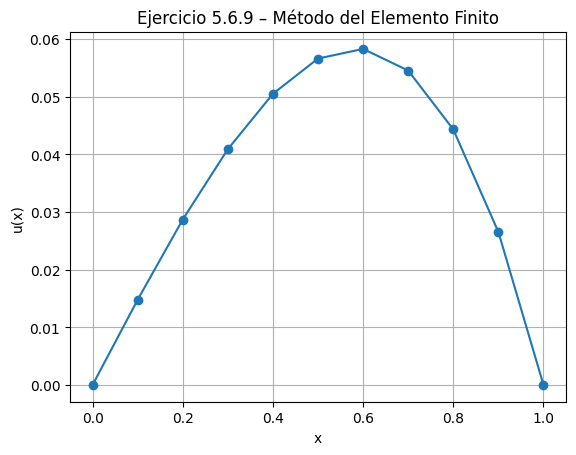

In [11]:
plt.figure()
plt.plot(x_nodes, u, marker='o')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Ejercicio 5.6.9 – Método del Elemento Finito')
plt.grid()
plt.show()
